# Assignment 8

## Submit your .ipynb file to Gradescope by Tuesday, November 11th **by 10pm**

#### Import necessary libraries:

In [2]:
import statsmodels.formula.api as smf
import pandas as pd 

##### Run the code cell below to read the CSV file named `results.csv` in the `data` folder and print the first 5 rows of the dataset (using a quick alternative to `.iloc[:5,:]`). Browse the dataset. (We've seen this file before, it's part of the Formula One racing dataset)

In [3]:
df_results = pd.read_csv("data/results.csv")
display(df_results.head())

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1
1,2,18,2,2,3,5,2,2,2,8.0,58,+5.478,5696094,41,3,1:27.739,217.586,1
2,3,18,3,3,7,7,3,3,3,6.0,58,+8.163,5698779,41,5,1:28.090,216.719,1
3,4,18,4,4,5,11,4,4,4,5.0,58,+17.181,5707797,58,7,1:28.603,215.464,1
4,5,18,5,1,23,3,5,5,5,4.0,58,+18.014,5708630,43,1,1:27.418,218.385,1


### (1) Linear Regression

Consider the data in `results.csv` loaded above. We might guess that there is a simple linear relationship between the number of points scored by a driver ("points"), the number of laps completed by the driver ("laps"), and the driver's starting position ("grid"). In particular, a better starting position and a larger number of completed laps should lead to a higher number of points.

In particular, we expect that these three variables are related by the approximate equality:

$$ p_i \approx a\cdot \ell_i + b\cdot g_i + c$$

where:

- $i$ is the index of the result (row $i$ of the DataFrame)
- $p_i$ is the number of points scored in result $i$
- $\ell_i$ is the number of laps completed in result $i$
- $g_i$ is the starting "grid" position of result $i$.
- $a$, $b$, and $c$ are the the coefficients of the linear model we need to determine.

In this model, we say that "laps" and "grid" are both **independent variables** and "points" is the **dependent variable**.

- Use ``smf.ols`` (Ordinary Least Squares) to compute the 3 coefficients of the model by running the following line of code (the names "independent_var/dependent_var1/dependent_var2" are placeholder names - substitute the appropriate column names from ``df_results``):
```python
model = smf.ols(formula = "independent_var ~ dependent_var1 + dependent_var2", 
    data = df_results)
```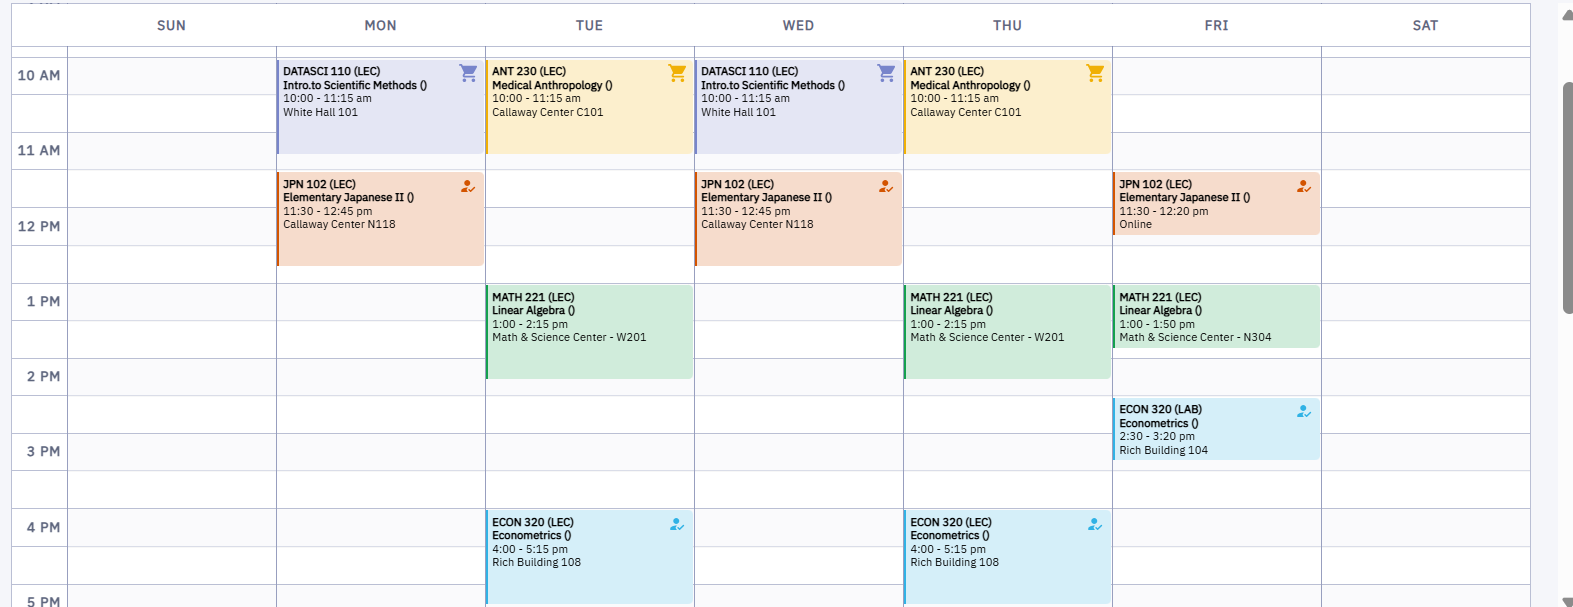
- Compute a Pandas ``Series`` containing the computed coefficients $a$, $b$, and $c$ from the linear model. You can do this as follows:
```python
        coeffs = model.fit().params
```
- Assign the entries of ``coeffs`` to 3 floating-point variables ``a``, ``b``, ``c`` corresponding to the coefficients of the model.

- Define two variables ``grid_val = 3`` and ``laps_val = 55``, which represent the position (grid) and completed laps, respectively, for a given driver. Using these values and the model coefficients, calculate how many points the linear model predicts for this driver, assigning it to the variable ``predicted_points``

In [4]:
# your answer here
model = smf.ols(formula="points ~ laps + grid", data=df_results)
coeffs = model.fit().params
a = float(coeffs.Intercept)
b = float(coeffs.laps)
c = float(coeffs.grid)

grid_val = 3
laps_val = 55
predicted_points = a + b * grid_val + c * laps_val
print(f"Predicted outcome for grid={grid_val} and laps={laps_val}: {predicted_points}")


Predicted outcome for grid=3 and laps=55: -9.661805624231071


##### Run the code cell below to read the CSV file named `imdb_top_1000.csv` in the `data` folder and print the first 5 rows of the dataset (using a quick alternative to `.iloc[:5,:]`). Browse the dataset. (These are the 1000 movies with highest score on imdb.com as of 5 years ago)

##### We will use this dataset for the remaining problems.

In [5]:
df_movies = pd.read_csv("data/imdb_top_1000.csv")
display(df_movies.head())

,Name,Released_Year,Length,Genre,IMDB_Rating,Overview,Director,Star1,Star2,Gross
0,The Shawshank Redemption,1994,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,Frank Darabont,Tim Robbins,Morgan Freeman,"28,341,469"
1,The Godfather,1972,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,Francis Ford Coppola,Marlon Brando,Al Pacino,"134,966,411"
2,The Dark Knight,2008,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,Christopher Nolan,Christian Bale,Heath Ledger,"534,858,444"
3,The Godfather: Part II,1974,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,Francis Ford Coppola,Al Pacino,Robert De Niro,"57,300,000"
4,12 Angry Men,1957,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,Sidney Lumet,Henry Fonda,Lee J. Cobb,"4,360,000"


### (2) Groupby + Aggregate Statistics

Create a new DataFrame by grouping the "movies" dataset by **"Genre"** and then computing the following aggregate statistics for **"IMDB_Rating"**:

- **Mean**
- **Standard Deviation**
- **Minimum**
- **Maximum**

Finally sort the DataFrame by the mean IMDB rating in **descending order**. Save the final sorted DataFrame as ``movies_agg``, and display (or print) it as output.

In [8]:
# your answer here
df_movies_agg = df_movies.groupby("Genre").agg(
    IMDB_mean = ("IMDB_Rating", "mean"),
    IMDB_std = ("IMDB_Rating", "std"),
    min_IMDB = ("IMDB_Rating", "min"),
    max_IMDB = ("IMDB_Rating", "max")
).sort_values(by="IMDB_mean", ascending=False).reset_index()
display(df_movies_agg)


,Genre,IMDB_mean,IMDB_std,min_IMDB,max_IMDB
0,"Animation, Drama, War",8.50,NaN,8.5,8.5
1,"Action, Sci-Fi",8.40,0.360555,8.0,8.7
2,"Drama, Musical",8.40,NaN,8.4,8.4
3,"Drama, Mystery, War",8.35,0.070711,8.3,8.4
4,Western,8.35,0.420317,7.8,8.8
...,...,...,...,...,...
197,"Action, Adventure, Mystery",7.60,NaN,7.6,7.6
198,"Action, Adventure, Family",7.60,NaN,7.6,7.6
199,"Action, Adventure, Crime",7.60,NaN,7.6,7.6
200,"Animation, Drama, Romance",7.60,NaN,7.6,7.6


### (3) Merge Data

Create a new DataFrame ``movies_merge`` by merging the aggregate information <br> 
from (2) into ``df_movies``. Treat ``df_movies`` as both the primary dataset and the "left" dataset.

Display (or print) the resulting DataFrame.

In [12]:
# your answer here
movies_merge = pd.merge(df_movies, df_movies_agg, on="Genre", how="left")
print(movies_merge)

                         Name Released_Year   Length  \
0    The Shawshank Redemption          1994  142 min   
1               The Godfather          1972  175 min   
2             The Dark Knight          2008  152 min   
3      The Godfather: Part II          1974  202 min   
4                12 Angry Men          1957   96 min   
..                        ...           ...      ...   
995    Breakfast at Tiffany's          1961  115 min   
996                     Giant          1956  201 min   
997     From Here to Eternity          1953  118 min   
998                  Lifeboat          1944   97 min   
999              The 39 Steps          1935   86 min   

                        Genre  IMDB_Rating  \
0                       Drama          9.3   
1                Crime, Drama          9.2   
2        Action, Crime, Drama          9.0   
3                Crime, Drama          9.0   
4                Crime, Drama          9.0   
..                        ...          ...   
995  

### (4) Renaming Columns

Create a new DataFrame ``movies_rename`` by renaming the following columns in ``df_movies``:

- "Name" --> **"Movie_Title"**
- "Length" --> **"Runtime"**
- "Gross" --> **"Revenue"**

Verify that this renaming worked by printing the column names of both the old DataFrame ("df_movies") and the new DataFrame ("movies_rename").

In [16]:
# your answer here

movies_rename = df_movies.rename(columns={"Name": "Movie_Title","Length": "Runtime","Gross":"Revenue"})
print(df_movies.columns)
print(movies_rename.columns)


Index(['Name', 'Released_Year', 'Length', 'Genre', 'IMDB_Rating', 'Overview',
       'Director', 'Star1', 'Star2', 'Gross'],
      dtype='object')
Index(['Movie_Title', 'Released_Year', 'Runtime', 'Genre', 'IMDB_Rating',
       'Overview', 'Director', 'Star1', 'Star2', 'Revenue'],
      dtype='object')


### (5) Split Data

Use ".query()" to split the ``movies_rename`` dataset from (4) into different parts:

- Those directed by **David Lynch**, saved to a DataFrame called ``movies_lynch``
- Those directed by **Stanley Kubrick**, saved to a DataFrame called ``movies_kubrick``

Display/print both DataFrames to the screen.

In [ ]:
# your answer here

movies_lynch = movies_rename.query("Director == 'David Lynch'")
movies_kubrick = movies_rename.query("Director == 'Stanley Kubrick'")
print(movies_lynch)
print(movies_kubrick)


            Movie_Title Released_Year  Runtime                     Genre  \
276    The Elephant Man          1980  124 min          Biography, Drama   
385  The Straight Story          1999  112 min          Biography, Drama   
515      Mulholland Dr.          2001  147 min  Drama, Mystery, Thriller   
834         Blue Velvet          1986  120 min  Drama, Mystery, Thriller   
961        Lost Highway          1997  134 min         Mystery, Thriller   

     IMDB_Rating                                           Overview  \
276          8.1  A Victorian surgeon rescues a heavily disfigur...   
385          8.0  An old man makes a long journey by lawnmower t...   
515          7.9  After a car wreck on the winding Mulholland Dr...   
834          7.7  The discovery of a severed human ear found in ...   
961          7.6  Anonymous videotapes presage a musician's murd...   

        Director                Star1              Star2    Revenue  
276  David Lynch      Anthony Hopkins         

In [19]:
print(movies_kubrick)


                                           Movie_Title Released_Year  Runtime  \
73                                         The Shining          1980  146 min   
78   Dr. Strangelove or: How I Learned to Stop Worr...          1964   95 min   
80                                      Paths of Glory          1957   88 min   
104                                  Full Metal Jacket          1987  116 min   
113                                 A Clockwork Orange          1971  136 min   
114                              2001: A Space Odyssey          1968  149 min   
281                                       Barry Lyndon          1975  185 min   
441                                        The Killing          1956   84 min   
549                                          Spartacus          1960  197 min   

                           Genre  IMDB_Rating  \
73                 Drama, Horror          8.4   
78                        Comedy          8.4   
80                    Drama, War          